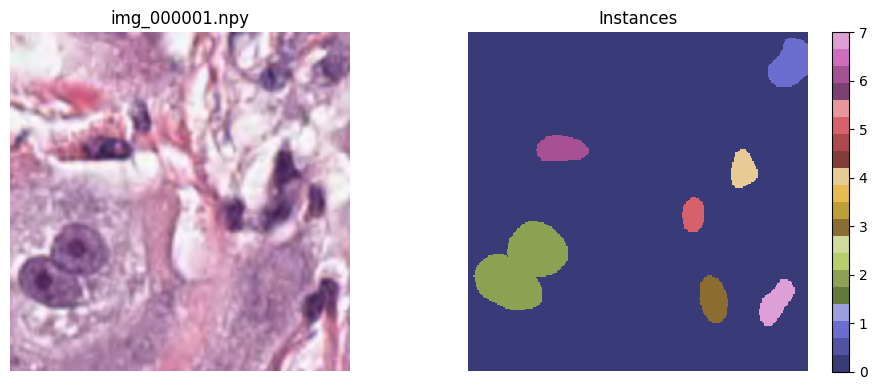

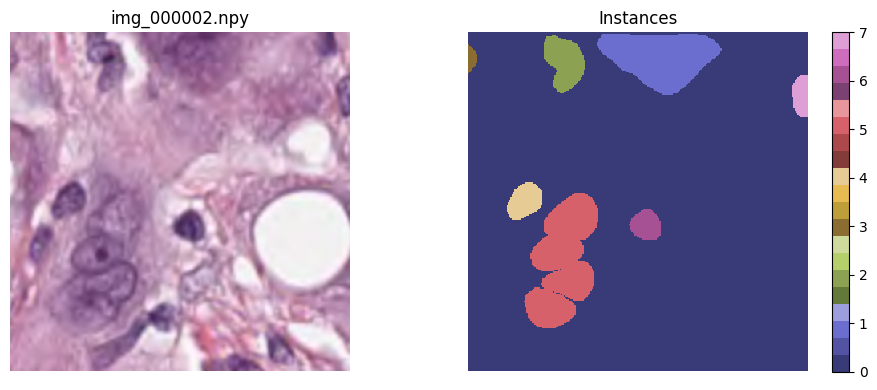

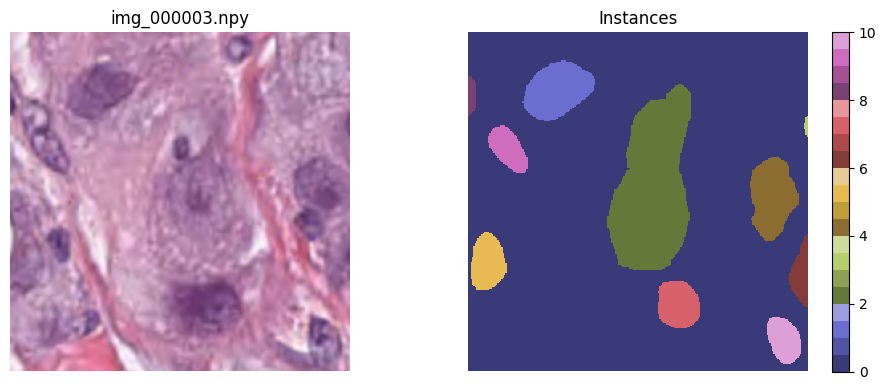

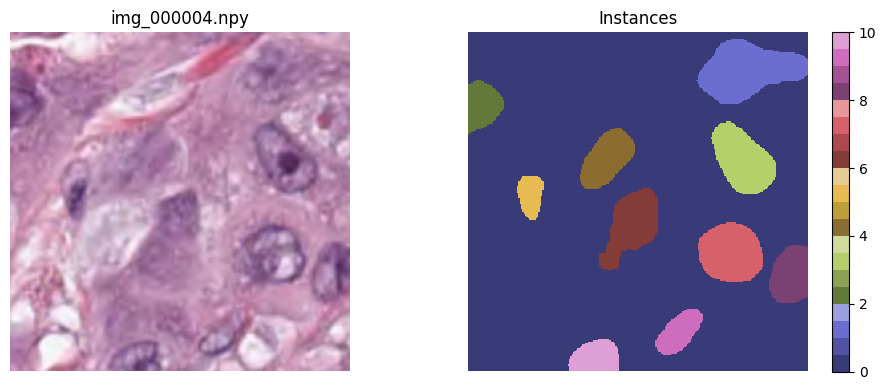

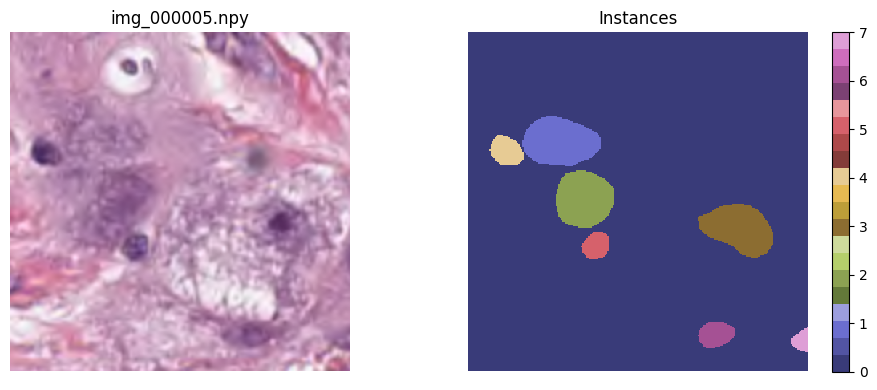

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/run/user/1000/gvfs/smb-share:server=zeus.pasteur.fr,share=bia/ayehadji/projet0")
root = base_dir / "data" / "prepared" / "pannuke" / "train"

img_files = sorted((root / "images").glob("img_*.npy"))[:5]

for img_path in img_files:
    mask_path = root / "masks" / img_path.name.replace("img_", "mask_")

    img = np.load(img_path)          # (H, W, 3), float32 [0,1]
    mask = np.load(mask_path)        # (H, W), uint16

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title(img_path.name)
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Instances")
    plt.imshow(mask, interpolation="nearest", cmap="tab20b")
    plt.colorbar()
    plt.axis("off")

    plt.tight_layout()
    plt.show()


   split           image  label    area   perimeter  eccentricity  solidity  \
0  train  img_000001.npy      1   831.0  110.669048      0.750877  0.948630   
1  train  img_000001.npy      2  2955.0  238.793939      0.767371  0.905608   
2  train  img_000001.npy      3   588.0   94.426407      0.827741  0.951456   
3  train  img_000001.npy      4   431.0   79.941125      0.733447  0.955654   
4  train  img_000001.npy      5   354.0   70.284271      0.762603  0.959350   

   circularity  centroid_row  centroid_col  
0     0.852626     24.308063    241.968712  
1     0.651210    177.234179     40.253469  
2     0.828706    201.634354    184.549320  
3     0.847513    103.904872    206.733179  
4     0.900527    137.793785    169.327684  
                area      perimeter   eccentricity       solidity  \
count  166446.000000  166446.000000  166446.000000  166446.000000   
mean      520.086539      85.790526       0.753482       0.943749   
std       507.066639      50.333365       0.1690

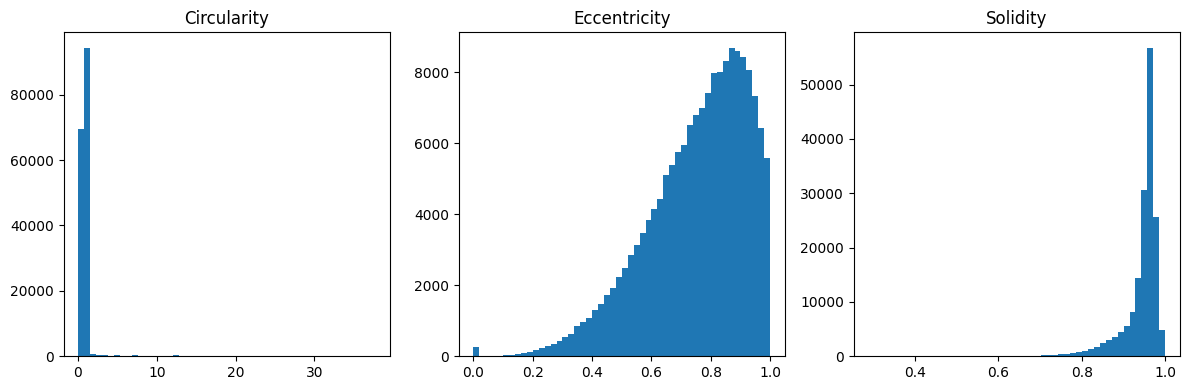

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("/run/user/1000/gvfs/smb-share:server=zeus.pasteur.fr,share=bia/ayehadji/projet0")
csv_path = base_dir / "data" / "prepared" / "pannuke" / "pannuke_morphology_features.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.describe()[["area", "perimeter", "eccentricity", "solidity", "circularity"]])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(df["circularity"].dropna(), bins=50)
plt.title("Circularity")

plt.subplot(1,3,2)
plt.hist(df["eccentricity"].dropna(), bins=50)
plt.title("Eccentricity")

plt.subplot(1,3,3)
plt.hist(df["solidity"].dropna(), bins=50)
plt.title("Solidity")

plt.tight_layout()
plt.show()


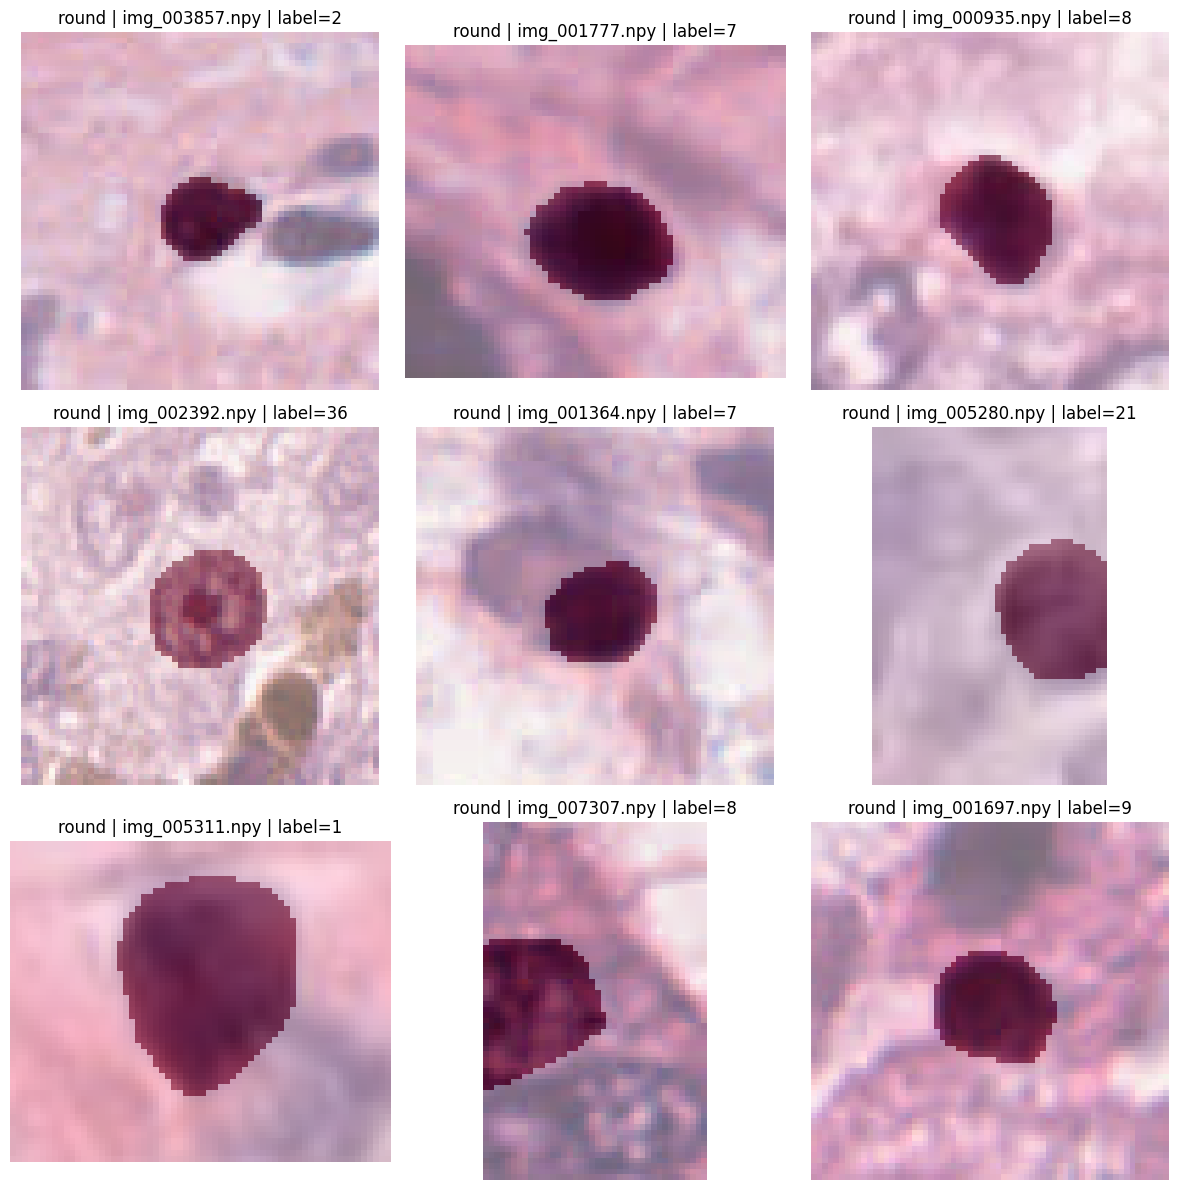

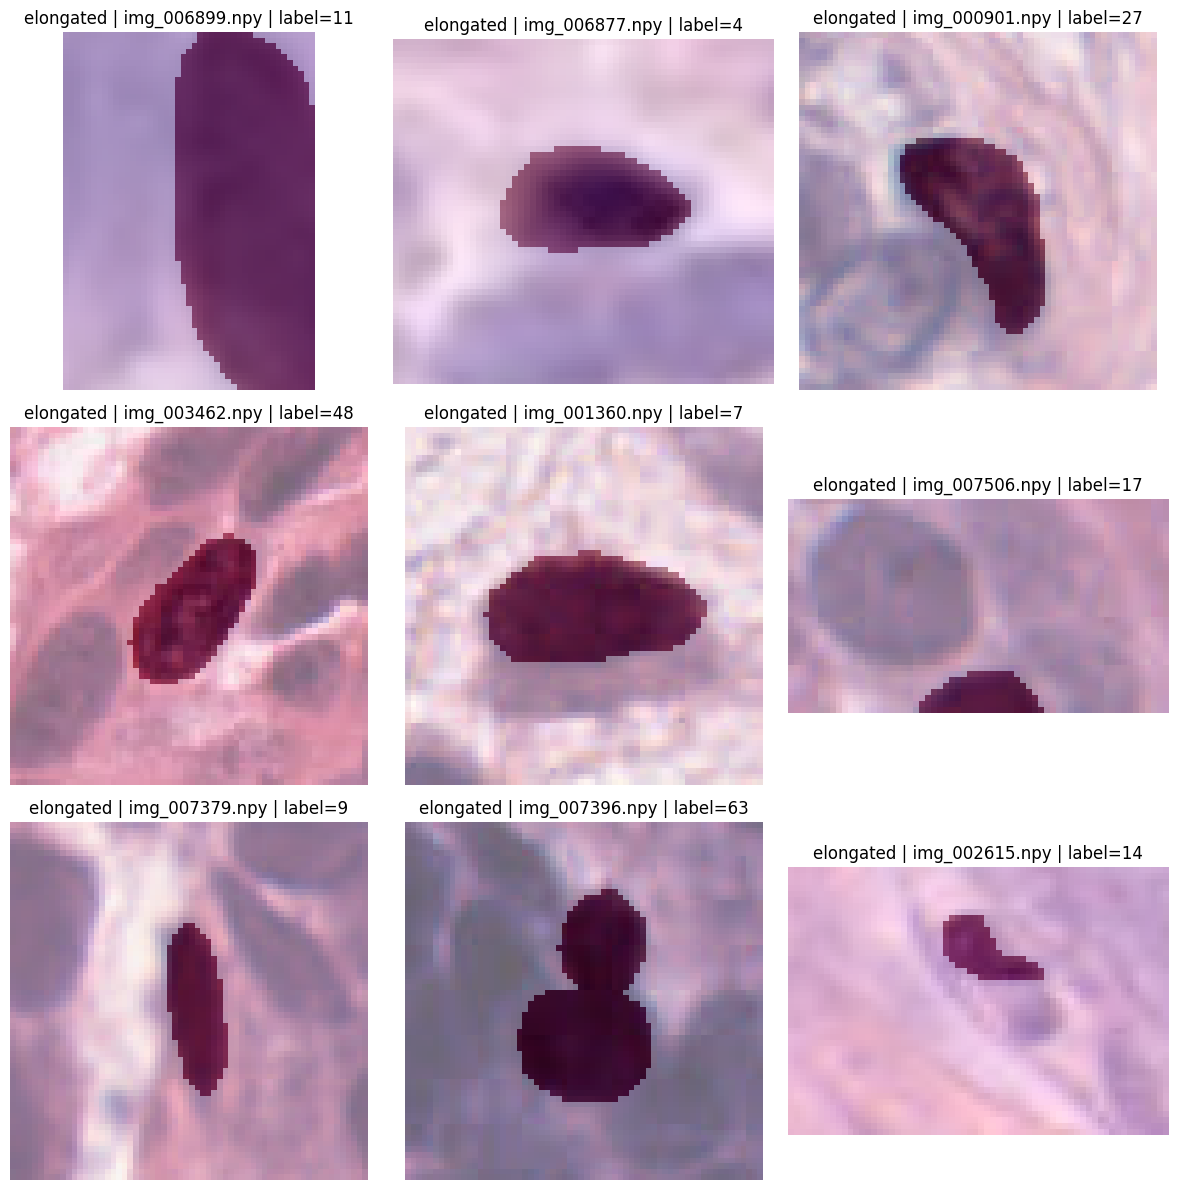

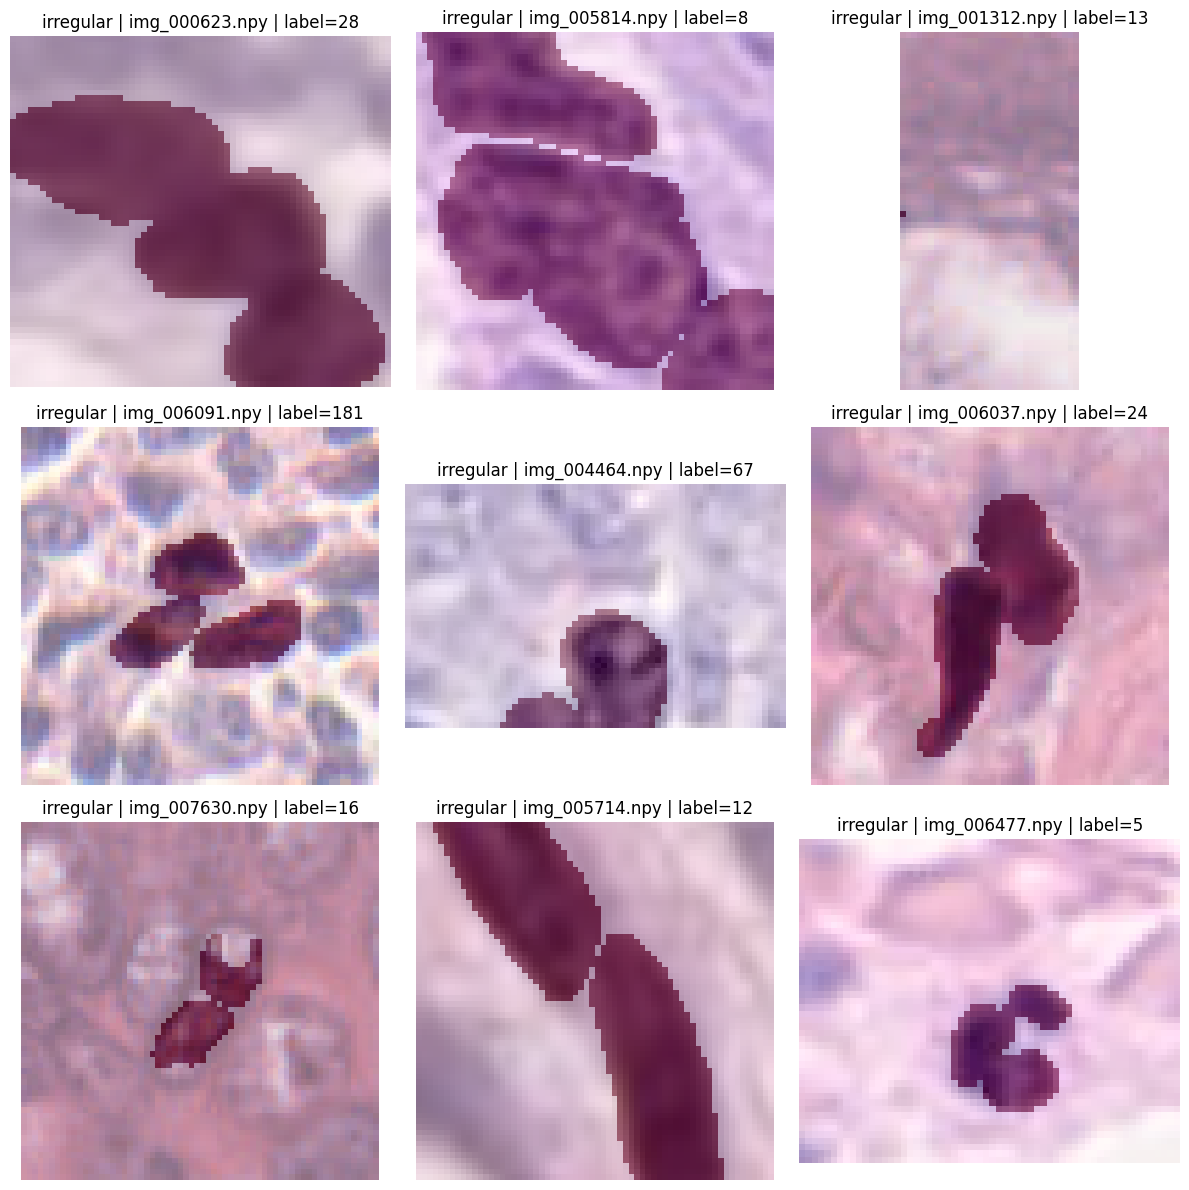

In [6]:
base_dir = Path("/run/user/1000/gvfs/smb-share:server=zeus.pasteur.fr,share=bia/ayehadji/projet0")
prep_root = base_dir / "data" / "prepared" / "pannuke"
csv_path = prep_root / "pannuke_morphology_with_classes.csv"

df = pd.read_csv(csv_path)

def show_examples(morph_class="round", n=9, crop_size=64):
    sub = df[df["morph_class"] == morph_class].sample(min(n, len(df)), random_state=42)

    n_cols = 3
    n_rows = int(np.ceil(len(sub) / n_cols))

    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    for i, row in enumerate(sub.itertuples(), start=1):
        split = row.split
        img_name = row.image
        label = row.label

        img_path = prep_root / split / "images" / img_name
        mask_path = prep_root / split / "masks" / img_name.replace("img_", "mask_")

        img = np.load(img_path)          # (H, W, 3)
        mask = np.load(mask_path)        # (H, W)

        # masque binaire de cette instance
        inst_mask = (mask == label)

        # centroid
        r = int(row.centroid_row)
        c = int(row.centroid_col)

        half = crop_size // 2
        r0, r1 = max(0, r - half), min(img.shape[0], r + half)
        c0, c1 = max(0, c - half), min(img.shape[1], c + half)

        img_crop = img[r0:r1, c0:c1, :]
        mask_crop = inst_mask[r0:r1, c0:c1]

        plt.subplot(n_rows, n_cols, i)
        plt.imshow(img_crop)
        plt.imshow(mask_crop, alpha=0.4, cmap="Reds")
        plt.axis("off")
        plt.title(f"{morph_class} | {img_name} | label={label}")

    plt.tight_layout()
    plt.show()

# Exemples :
show_examples("round", n=9)
show_examples("elongated", n=9)
show_examples("irregular", n=9)
